# Exploratory Data Analysis (EDA)

### Coding Camp 2026 | Tim CC26-PSU060

EDA ini bertujuan untuk mengeksplorasi karakteristik data sebelum masuk ke tahap pemodelan.
Dataset yang digunakan:
1. `cleaned_job_5.csv` — Dataset lowongan kerja (2.516 entri)
2. `cleaned_training_data.csv` — Dataset resume pelamar (10.000 entri)
3. `skkni_reference_clean.csv` — Referensi unit kompetensi SKKNI (662 entri)
4. `skill_mapping_dictionary.csv` — Kamus pemetaan skill internasional ke SKKNI (114 entri)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import ast
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "sans-serif"

## EDA — Dataset Lowongan Kerja (`cleaned_job_5.csv`)


In [3]:
jobs    = pd.read_csv("cleaned_job_5.csv")
resumes = pd.read_csv("cleaned_training_data.csv")
skkni   = pd.read_csv("skkni_reference_clean.csv")
skill_map = pd.read_csv("skill_mapping_dictionary.csv")

daftar_skill_resmi = set(skill_map['Skill_Internasional_Kaggle'].str.lower().dropna().unique())

print(f"Jobs    : {jobs.shape[0]:,} baris, {jobs.shape[1]} kolom")
print(f"Resumes : {resumes.shape[0]:,} baris, {resumes.shape[1]} kolom")
print(f"SKKNI   : {skkni.shape[0]:,} baris, {skkni.shape[1]} kolom")
print(f"SkillMap: {skill_map.shape[0]:,} baris, {skill_map.shape[1]} kolom")

Jobs    : 2,516 baris, 18 kolom
Resumes : 10,000 baris, 9 kolom
SKKNI   : 662 baris, 4 kolom
SkillMap: 114 baris, 4 kolom


In [4]:
# Info & Missing Values (Jobs)
print("INFO DATASET JOBS")
jobs.info()
print("\n MISSING VALUES (%)")
missing_pct = (jobs.isnull().sum() / len(jobs) * 100).sort_values(ascending=False)
print(missing_pct[missing_pct > 0].round(2).to_string())

INFO DATASET JOBS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2516 entries, 0 to 2515
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   logo                 2467 non-null   object
 1   title                2516 non-null   object
 2   company              2516 non-null   object
 3   location             2409 non-null   object
 4   min_company_size     2516 non-null   int64 
 5   max_company_size     2516 non-null   int64 
 6   type_of_work         766 non-null    object
 7   requirement          2344 non-null   object
 8   job_level            299 non-null    object
 9   description          1995 non-null   object
 10  min_work_experience  2516 non-null   int64 
 11  max_work_experience  2516 non-null   int64 
 12  qualification        1806 non-null   object
 13  currency             490 non-null    object
 14  min_salary           2516 non-null   int64 
 15  max_salary           2516 non-null   

**Insight:**

Berdasarkan hasil Exploratory Data Analysis (EDA), ditemukan beberapa kolom memiliki missing value dengan persentase yang cukup tinggi, seperti `job_level`, `currency`, dan `type_of_work`.

Tingginya missing value pada beberapa kolom disebabkan karena terdapat data yang memang tidak memiliki informasi lengkap dari sumber dataset asli. Selain itu, pada proses sebelumnya beberapa data kosong direpresentasikan menggunakan nilai `None` agar struktur data tetap terjaga dan baris data tidak terhapus.

Meskipun demikian, kolom-kolom utama yang digunakan dalam proses analisis dan pemodelan, seperti `title`, `requirement`, dan `description`, masih memiliki jumlah data yang memadai sehingga dataset tetap layak digunakan untuk tahap analisis lebih lanjut.

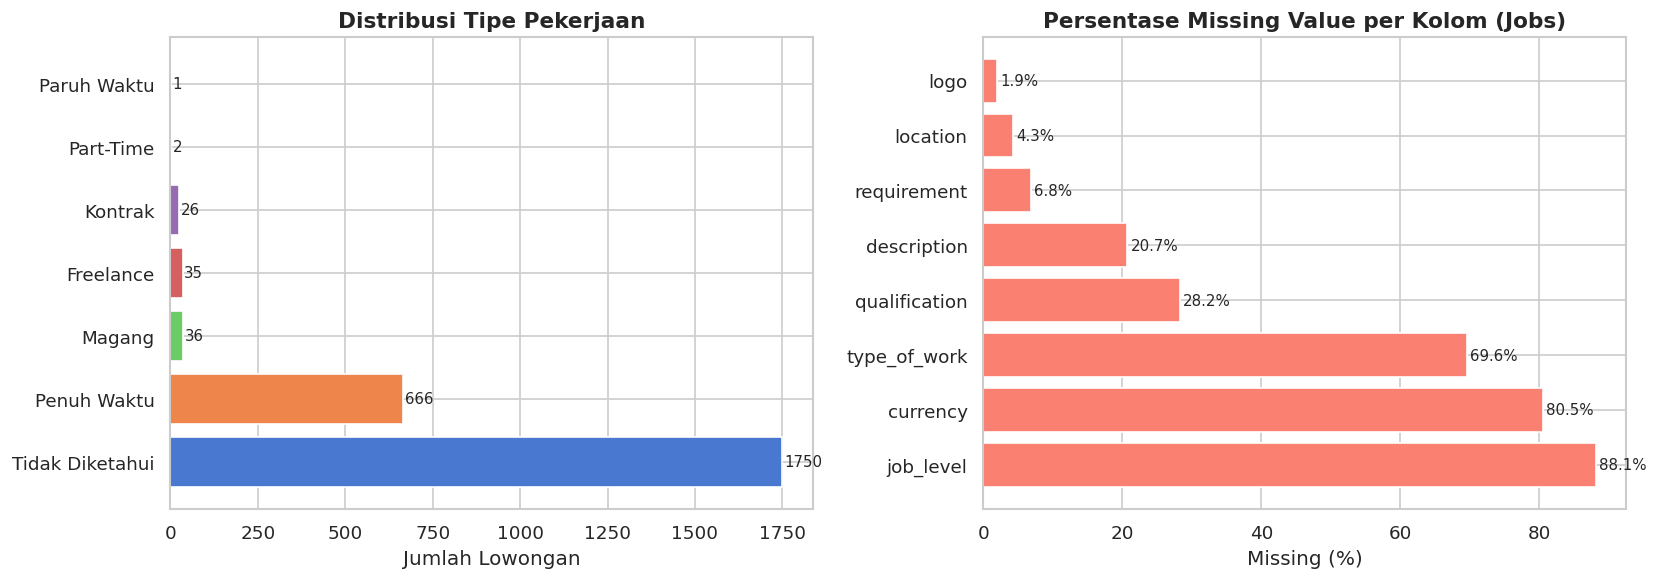

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
#Type of work
type_counts = jobs["type_of_work"].fillna("Tidak Diketahui").value_counts()
axes[0].barh(type_counts.index, type_counts.values, color=sns.color_palette("muted", len(type_counts)))
axes[0].set_title("Distribusi Tipe Pekerjaan", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Jumlah Lowongan")
for i, v in enumerate(type_counts.values):
    axes[0].text(v + 5, i, str(v), va="center", fontsize=9)

# Missing value heatmap summary
missing_cols = missing_pct[missing_pct > 0]
axes[1].barh(missing_cols.index, missing_cols.values, color="salmon")
axes[1].set_title("Persentase Missing Value per Kolom (Jobs)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Missing (%)")
for i, v in enumerate(missing_cols.values):
    axes[1].text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("eda_jobs_overview.png", bbox_inches="tight")
plt.show()

**Insight:**  
Distribusi data menunjukkan bahwa mayoritas lowongan pekerjaan termasuk kategori **Penuh Waktu**, sedangkan kategori magang dan freelance memiliki jumlah yang lebih sedikit. Tingginya missing value pada atribut `type_of_work` disebabkan oleh keterbatasan informasi dari sumber dataset asli.

Pada tahap preprocessing, nilai kosong direpresentasikan sebagai **"Tidak Diketahui"** untuk mempertahankan integritas dataset dan mencegah hilangnya data akibat penghapusan baris.

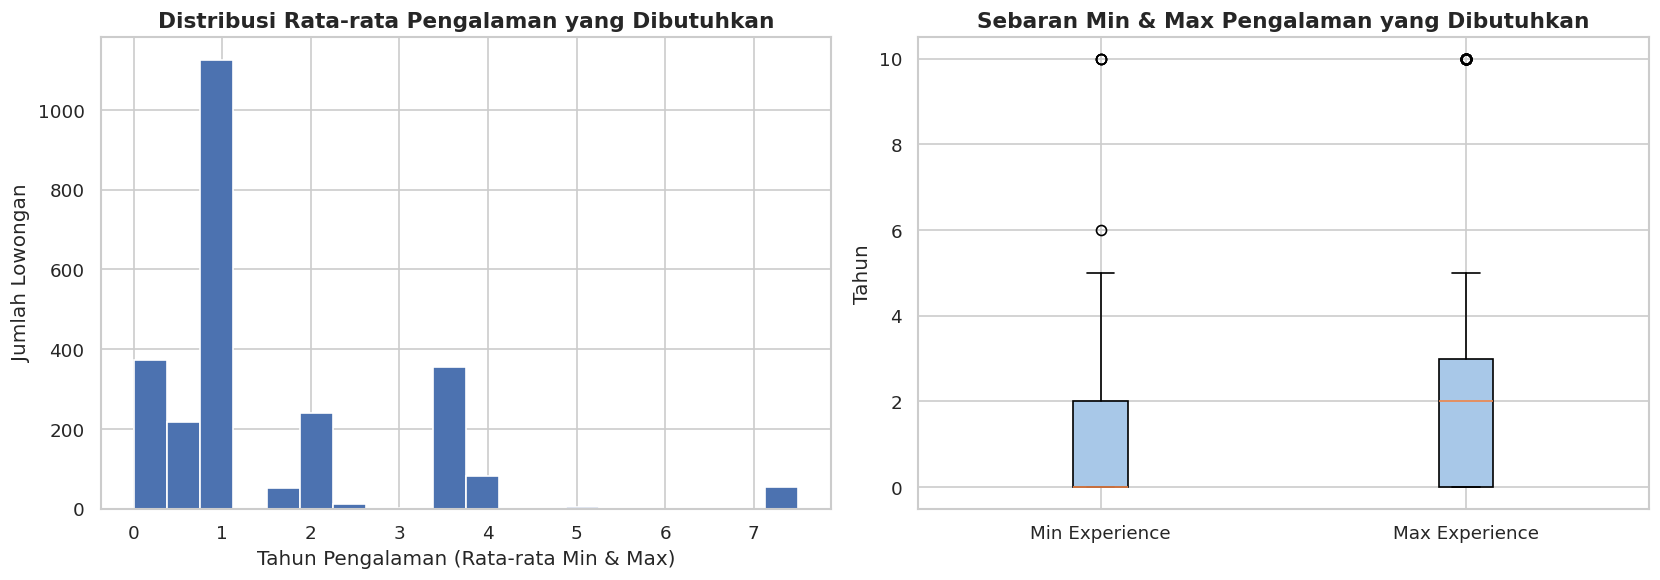

Statistik exp_mid:
count    2516.00
mean        1.52
std         1.46
min         0.00
25%         1.00
50%         1.00
75%         2.00
max         7.50
Name: exp_mid, dtype: float64


In [6]:
# Distribusi Pengalaman Kerja yang Dibutuhkan
jobs["exp_mid"] = (jobs["min_work_experience"] + jobs["max_work_experience"]) / 2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram exp_mid
axes[0].hist(jobs["exp_mid"], bins=20, color="#4c72b0", edgecolor="white")
axes[0].set_title("Distribusi Rata-rata Pengalaman yang Dibutuhkan", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Tahun Pengalaman (Rata-rata Min & Max)")
axes[0].set_ylabel("Jumlah Lowongan")

# Boxplot min vs max
axes[1].boxplot([jobs["min_work_experience"], jobs["max_work_experience"]],
                labels=["Min Experience", "Max Experience"],
                patch_artist=True,
                boxprops=dict(facecolor="#a8c8e8"))
axes[1].set_title("Sebaran Min & Max Pengalaman yang Dibutuhkan", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Tahun")

plt.tight_layout()
plt.savefig("eda_jobs_experience.png", bbox_inches="tight")
plt.show()

print("Statistik exp_mid:")
print(jobs["exp_mid"].describe().round(2))

**Insight:**

Distribusi pengalaman kerja menunjukkan bahwa sebagian besar lowongan berada pada rentang pengalaman **0–3 tahun**. Temuan ini mengindikasikan bahwa pasar kerja dalam dataset masih cukup terbuka bagi kandidat dengan pengalaman kerja awal atau level junior.

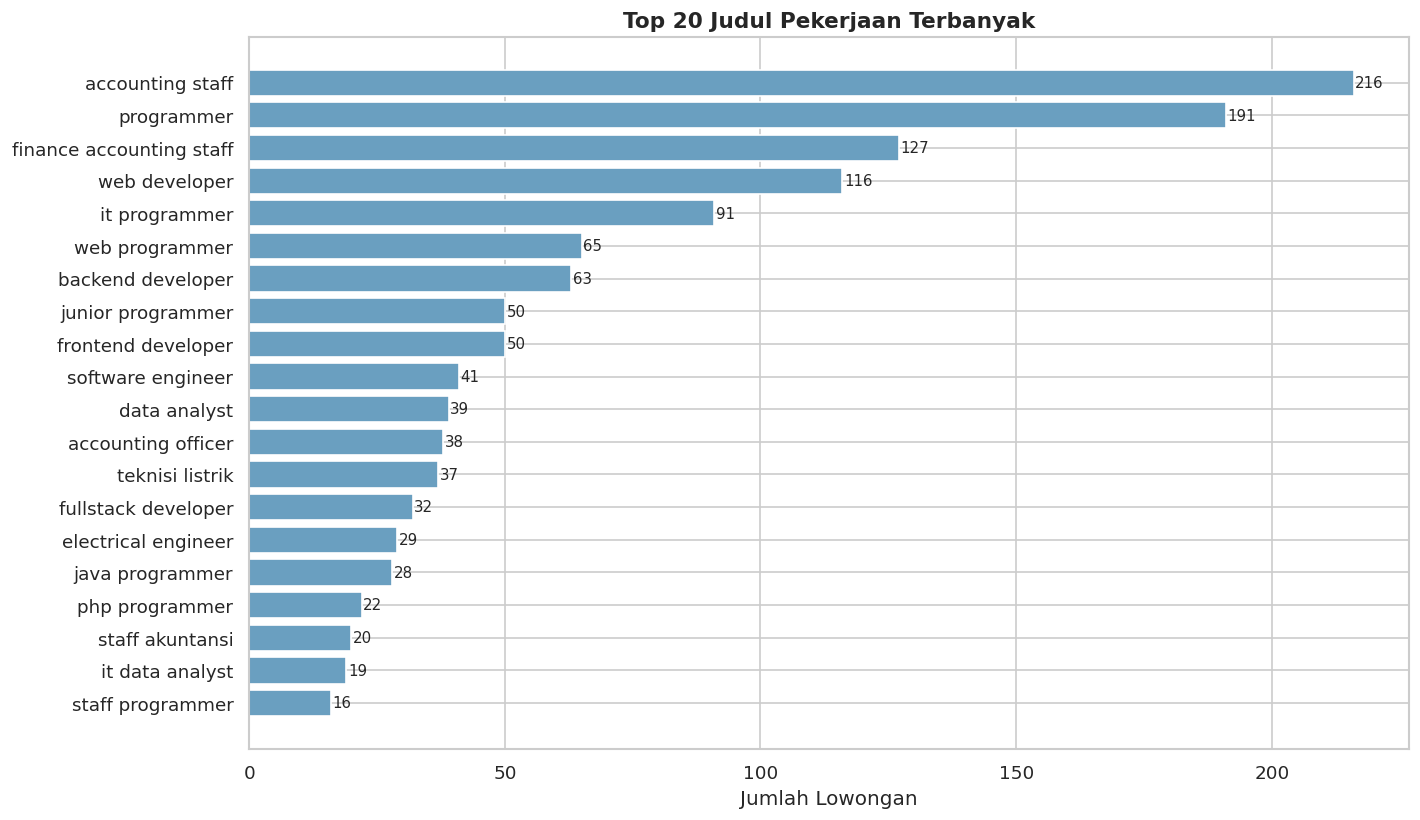

In [7]:
# Top 20 Judul Pekerjaan
title_counts = jobs["title"].str.lower().str.strip().value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(title_counts.index[::-1], title_counts.values[::-1], color="#6a9fc0")
ax.set_title("Top 20 Judul Pekerjaan Terbanyak", fontsize=13, fontweight="bold")
ax.set_xlabel("Jumlah Lowongan")
for i, v in enumerate(title_counts.values[::-1]):
    ax.text(v + 0.3, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.savefig("eda_top_jobs.png", bbox_inches="tight")
plt.show()

**Insight:**

Mayoritas lowongan pekerjaan pada dataset berasal dari bidang **Data Analyst, Data Scientist, dan Backend Developer**. Temuan ini menunjukkan bahwa dataset didominasi oleh kategori pekerjaan berbasis teknologi dan digital.

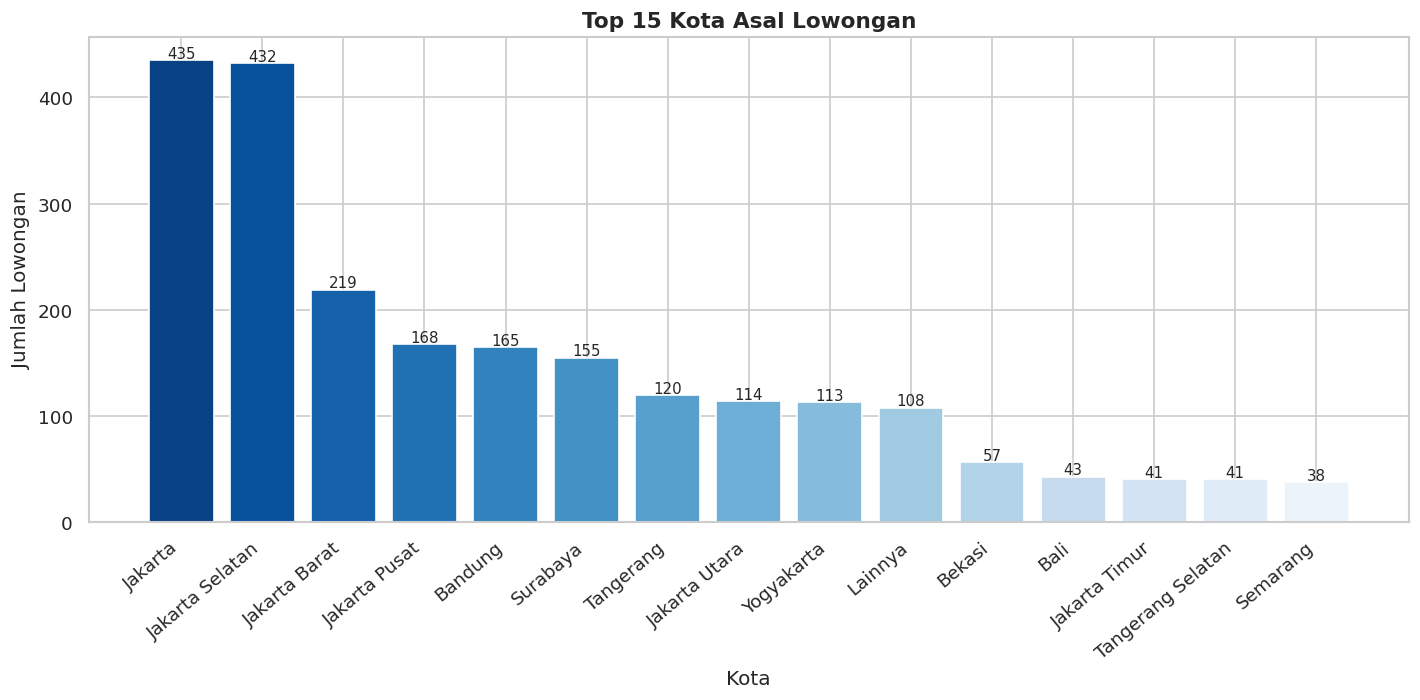

In [8]:
# Distribusi Lokasi Lowongan (Top 15 Kota)
CITY_MAP = {
    "jakarta selatan": "Jakarta Selatan", "jakarta barat": "Jakarta Barat",
    "jakarta pusat": "Jakarta Pusat", "jakarta utara": "Jakarta Utara",
    "jakarta timur": "Jakarta Timur", "jakarta raya": "Jakarta",
    "dki jakarta": "Jakarta", "jakarta": "Jakarta",
    "bandung": "Bandung", "surabaya": "Surabaya",
    "tangerang selatan": "Tangerang Selatan", "tangerang": "Tangerang",
    "bekasi": "Bekasi", "yogyakarta": "Yogyakarta",
    "sleman": "Yogyakarta", "semarang": "Semarang",
    "medan": "Medan", "depok": "Depok", "bogor": "Bogor",
    "malang": "Malang", "bali": "Bali", "denpasar": "Bali",
    "makassar": "Makassar", "palembang": "Palembang",
    "balikpapan": "Balikpapan",
}

def extract_city(loc):
    if pd.isna(loc): return "Lainnya"
    loc_lower = loc.lower()
    for key, val in CITY_MAP.items():
        if key in loc_lower: return val
    return loc.split(",")[0].strip().title()

jobs["kota"] = jobs["location"].apply(extract_city)
city_counts = jobs["kota"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(city_counts.index, city_counts.values, color=sns.color_palette("Blues_r", 15))
ax.set_title("Top 15 Kota Asal Lowongan", fontsize=13, fontweight="bold")
ax.set_xlabel("Kota")
ax.set_ylabel("Jumlah Lowongan")
plt.xticks(rotation=40, ha="right")
for i, v in enumerate(city_counts.values):
    ax.text(i, v + 2, str(v), ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("eda_kota.png", bbox_inches="tight")
plt.show()

**Insight:**

**Jakarta** (gabungan semua wilayah) mendominasi lowongan secara signifikan, mencerminkan sentralisasi industri digital di ibu kota. Namun ada pula Bandung, Surabaya, dan Yogyakarta yang menjadi pusat pertumbuhan digital di luar Jabodetabek.

## EDA — Dataset Resume Pelamar (`cleaned_training_data.csv`)

### Distribusi Kategori Profesi

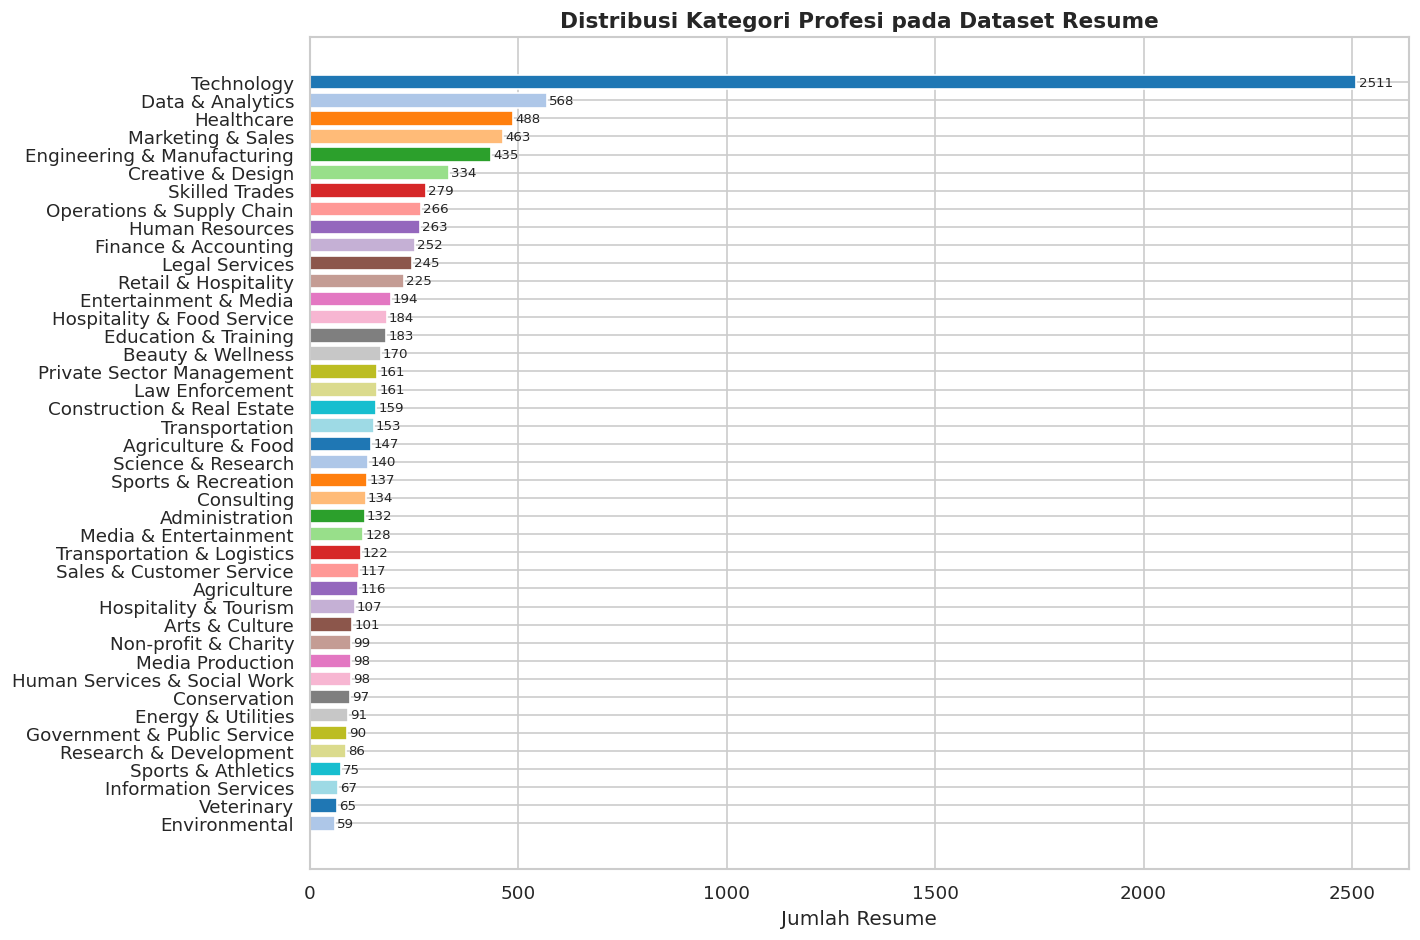


Jumlah kategori unik: 42
Kategori terbanyak  : Technology (2,511 resume)


In [9]:
# Distribusi Kategori Resume
cat_counts = resumes["Category"].value_counts()

fig, ax = plt.subplots(figsize=(12, 8))
colors = sns.color_palette("tab20", len(cat_counts))
ax.barh(cat_counts.index[::-1], cat_counts.values[::-1], color=colors[::-1])
ax.set_title("Distribusi Kategori Profesi pada Dataset Resume", fontsize=13, fontweight="bold")
ax.set_xlabel("Jumlah Resume")
for i, v in enumerate(cat_counts.values[::-1]):
    ax.text(v + 5, i, str(v), va="center", fontsize=8)
plt.tight_layout()
plt.savefig("eda_resume_category.png", bbox_inches="tight")
plt.show()

print(f"\nJumlah kategori unik: {resumes['Category'].nunique()}")
print(f"Kategori terbanyak  : {cat_counts.index[0]} ({cat_counts.iloc[0]:,} resume)")

**Insight:**

Kategori **Technology** mendominasi dataset resume dengan 2.511 entri (25,1%), diikuti oleh kategori **Data & Analytics** sebanyak 568 entri dan **Healthcare** sebanyak 488 entri. Hal ini menunjukkan bahwa dataset memiliki konsentrasi tinggi pada bidang pekerjaan berbasis teknologi dan data.

Secara keseluruhan, dataset mencakup **42 kategori profesi** yang beragam, menunjukkan variasi latar belakang pekerjaan yang cukup luas pada data resume.

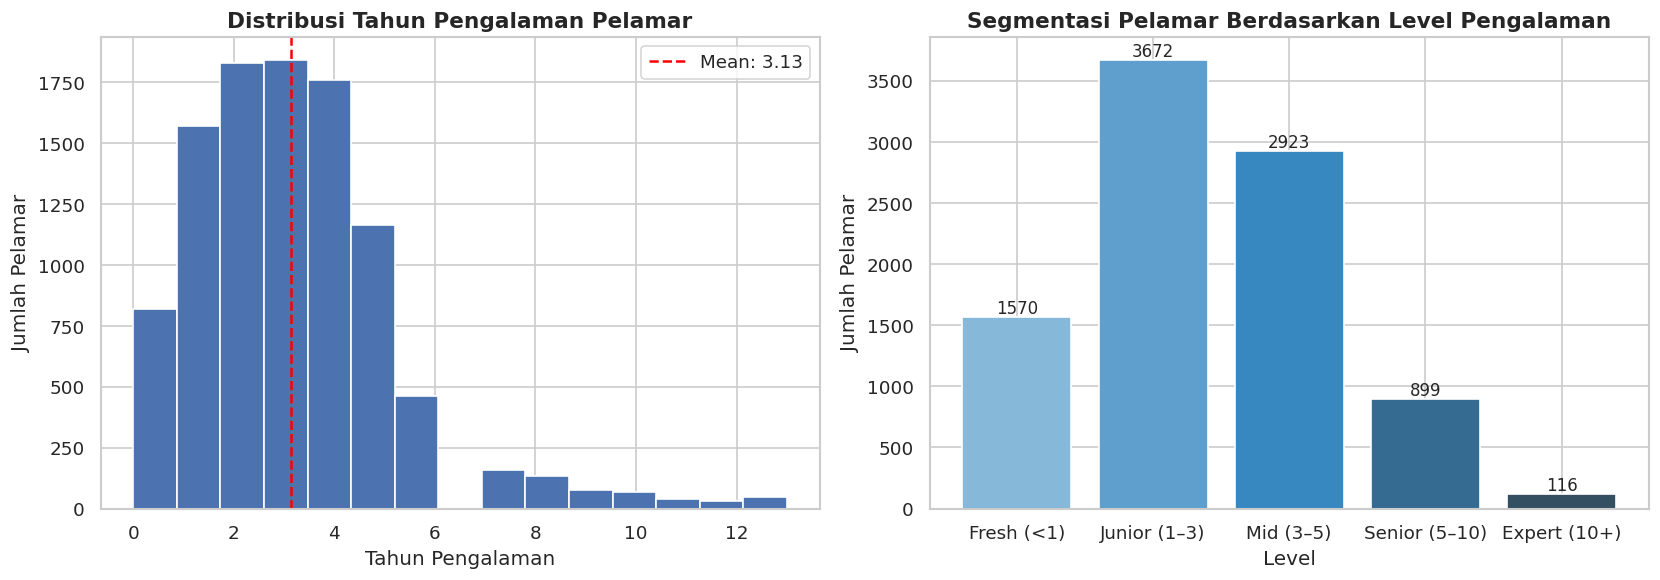

In [10]:
# Distribusi Pengalaman Pelamar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(resumes["Experience Years"], bins=15, color="#4c72b0", edgecolor="white")
axes[0].set_title("Distribusi Tahun Pengalaman Pelamar", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Tahun Pengalaman")
axes[0].set_ylabel("Jumlah Pelamar")
axes[0].axvline(resumes["Experience Years"].mean(), color="red", linestyle="--",
                label=f"Mean: {resumes['Experience Years'].mean():.2f}")
axes[0].legend()

# Bucket pengalaman
bins = [0, 1, 3, 5, 10, 100]
labels_bucket = ["Fresh (<1)", "Junior (1–3)", "Mid (3–5)", "Senior (5–10)", "Expert (10+)"]
resumes["exp_bucket"] = pd.cut(resumes["Experience Years"], bins=bins, labels=labels_bucket, right=True)
bucket_counts = resumes["exp_bucket"].value_counts().reindex(labels_bucket)

axes[1].bar(bucket_counts.index, bucket_counts.values,
            color=sns.color_palette("Blues_d", len(bucket_counts)))
axes[1].set_title("Segmentasi Pelamar Berdasarkan Level Pengalaman", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Level")
axes[1].set_ylabel("Jumlah Pelamar")
for i, v in enumerate(bucket_counts.values):
    axes[1].text(i, v + 30, str(v), ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("eda_resume_experience.png", bbox_inches="tight")
plt.show()

**Insight:**

Rata-rata pengalaman kerja pelamar berada pada angka **3,13 tahun**, dengan mayoritas berada pada segmen **Junior (1–3 tahun)** dan **Mid Level (3–5 tahun)**. Hal ini menunjukkan bahwa dataset didominasi oleh pelamar dengan pengalaman kerja awal hingga menengah.

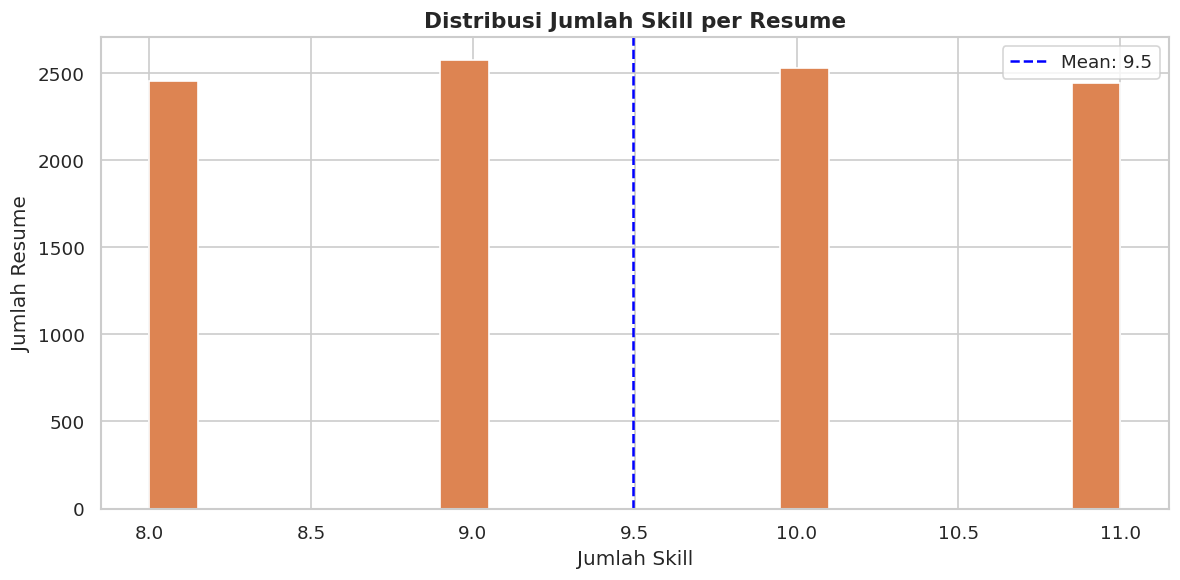

count    10000.00
mean         9.50
std          1.11
min          8.00
25%          9.00
50%          9.00
75%         10.00
max         11.00
Name: skill_count, dtype: float64


In [11]:
# Distribusi Jumlah Skill per Resume
def parse_skills(s):
    if pd.isna(s): return []
    try:
        parsed = ast.literal_eval(s)
        if isinstance(parsed, list): return parsed
    except: pass
    return [x.strip() for x in str(s).split("|") if x.strip()]

resumes["skills_list"] = resumes["skills_clean"].apply(parse_skills)
resumes["skill_count"]  = resumes["skills_list"].apply(len)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(resumes["skill_count"], bins=20, color="#dd8452", edgecolor="white")
ax.set_title("Distribusi Jumlah Skill per Resume", fontsize=13, fontweight="bold")
ax.set_xlabel("Jumlah Skill")
ax.set_ylabel("Jumlah Resume")
ax.axvline(resumes["skill_count"].mean(), color="blue", linestyle="--",
           label=f"Mean: {resumes['skill_count'].mean():.1f}")
ax.legend()
plt.tight_layout()
plt.savefig("eda_skill_count.png", bbox_inches="tight")
plt.show()

print(resumes["skill_count"].describe().round(2))

**Insight:**

Rata-rata pelamar memiliki **sekitar 8–9 skill** per resume. Distribusinya cukup normal dengan sedikit right-skew, artinya sebagian kecil pelamar mencantumkan sangat banyak skill (bisa jadi noise).

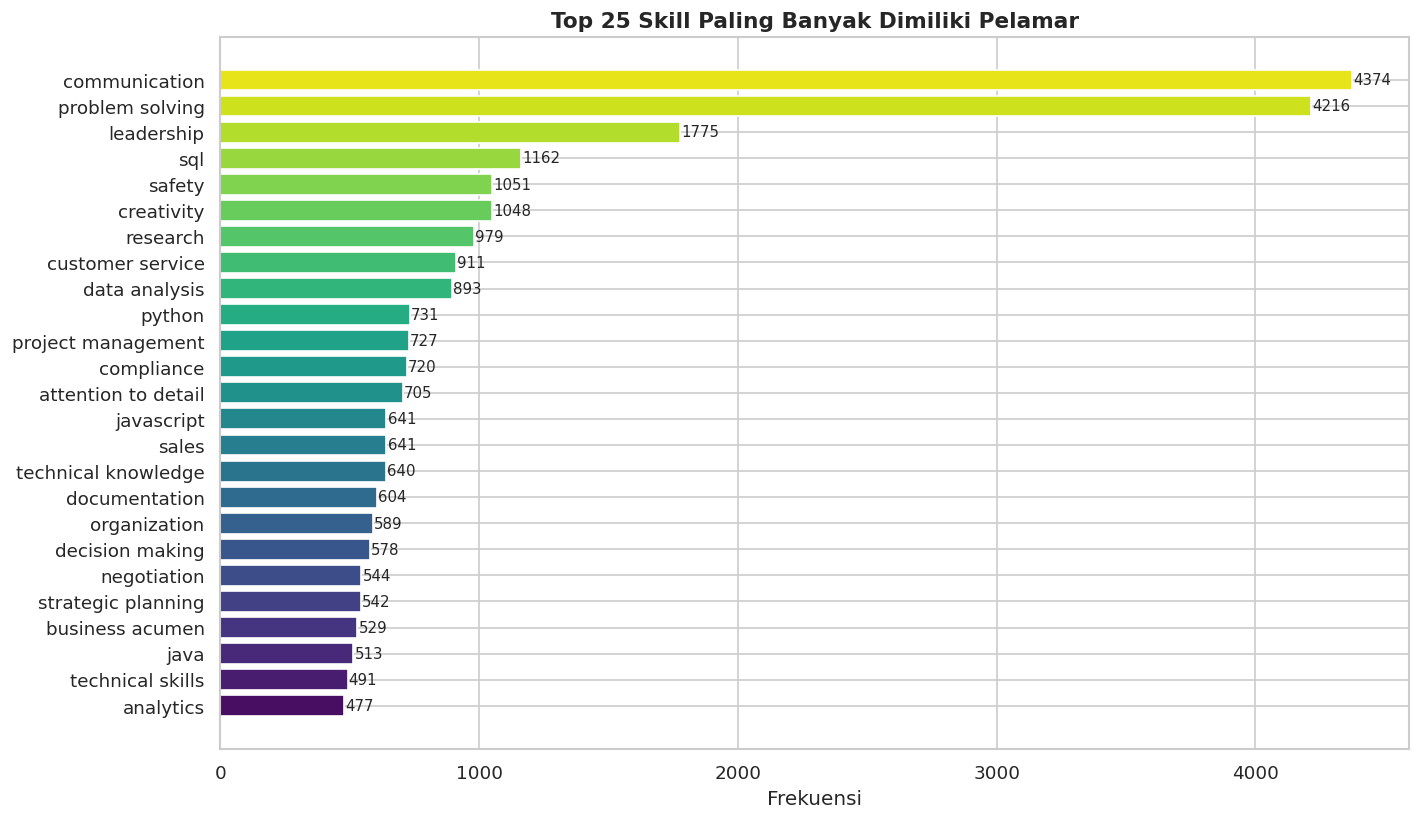

In [12]:
# Top 25 Skill Terbanyak di Resume
all_skills = []
for lst in resumes["skills_list"]:
    all_skills.extend([s.lower().strip() for s in lst])

skill_freq = Counter(all_skills).most_common(25)
skill_df = pd.DataFrame(skill_freq, columns=["skill", "count"])

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(skill_df["skill"][::-1], skill_df["count"][::-1],
        color=sns.color_palette("viridis", 25))
ax.set_title("Top 25 Skill Paling Banyak Dimiliki Pelamar", fontsize=13, fontweight="bold")
ax.set_xlabel("Frekuensi")
for i, v in enumerate(skill_df["count"][::-1]):
    ax.text(v + 5, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.savefig("eda_top_skills_resume.png", bbox_inches="tight")
plt.show()

**Insight:**

Skill yang paling dominan pada dataset resume meliputi **Python, SQL, Machine Learning, Data Analysis,** dan **Communication**. Selain hard skill teknis, terdapat pula soft skill seperti **Communication** dan **Problem Solving** yang cukup sering muncul pada resume pelamar.

Hal ini menunjukkan bahwa proses pemetaan kompetensi terhadap SKKNI tidak hanya perlu mempertimbangkan kemampuan teknis, tetapi juga keterampilan non-teknis yang mendukung kebutuhan pekerjaan profesional.

## EDA — Dataset SKKNI (`skkni_reference_clean.csv`)

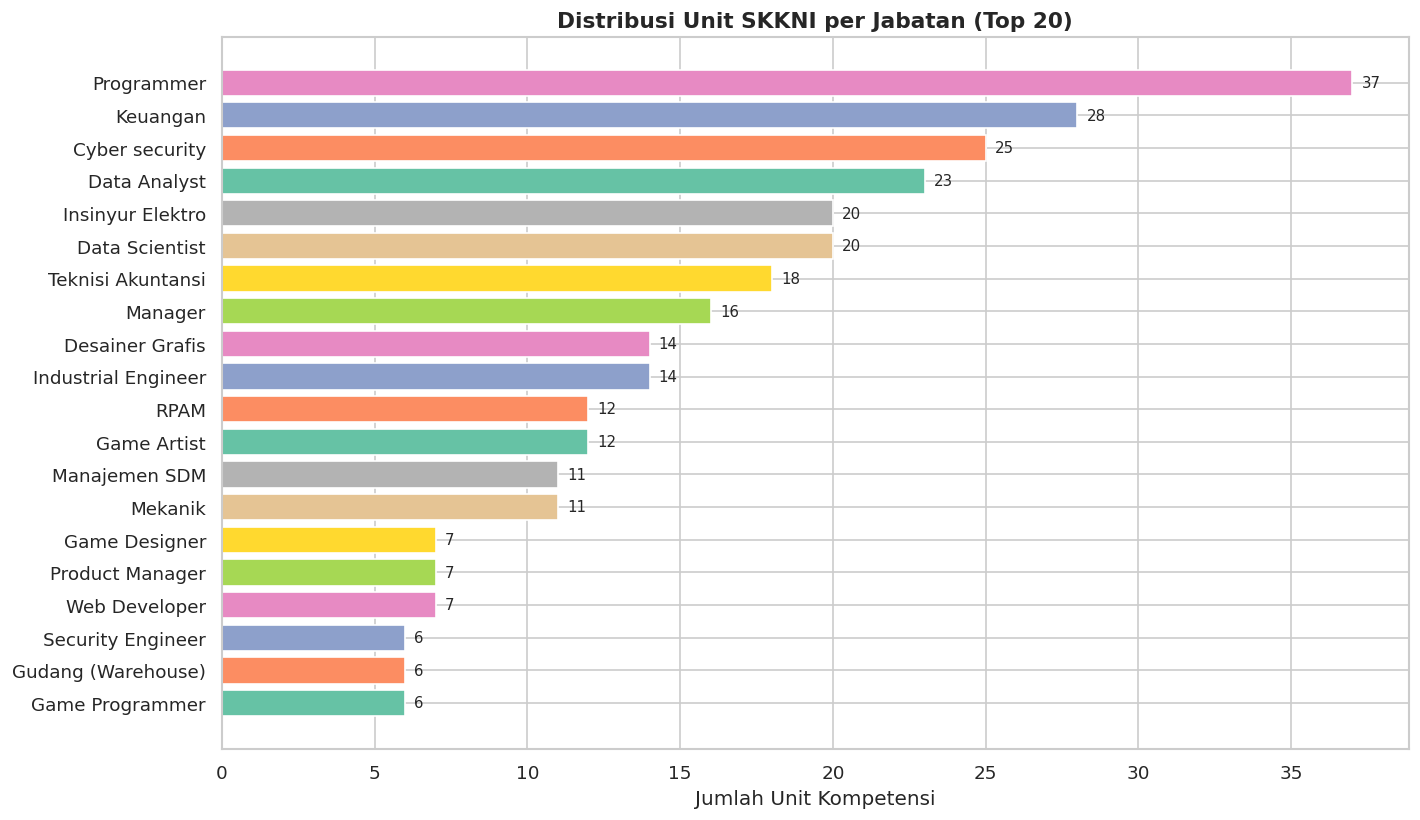


Total unit SKKNI unik: 412
Total jabatan unik   : 194


In [13]:
# Distribusi Unit SKKNI per Jabatan
jabatan_counts = skkni["Jabatan"].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(jabatan_counts.index[::-1], jabatan_counts.values[::-1],
        color=sns.color_palette("Set2", 20))
ax.set_title("Distribusi Unit SKKNI per Jabatan (Top 20)", fontsize=13, fontweight="bold")
ax.set_xlabel("Jumlah Unit Kompetensi")
for i, v in enumerate(jabatan_counts.values[::-1]):
    ax.text(v + 0.3, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.savefig("eda_skkni_jabatan.png", bbox_inches="tight")
plt.show()

print(f"\nTotal unit SKKNI unik: {skkni['Kode Unit'].nunique()}")
print(f"Total jabatan unik   : {skkni['Jabatan'].nunique()}")

**Insight:**

Jabatan **Programmer** memiliki jumlah unit kompetensi SKKNI terbanyak, yaitu sebanyak **37 unit**, diikuti oleh bidang **Keuangan** sebanyak **28 unit** dan **Cyber Security** sebanyak **25 unit**.

Secara keseluruhan, lima bidang pekerjaan utama pada sektor digital dan profesional mencakup total **133 unit kompetensi SKKNI**. Hal ini menunjukkan bahwa dataset SKKNI memiliki cakupan kompetensi yang cukup luas untuk proses pemetaan dan matching kompetensi kerja.

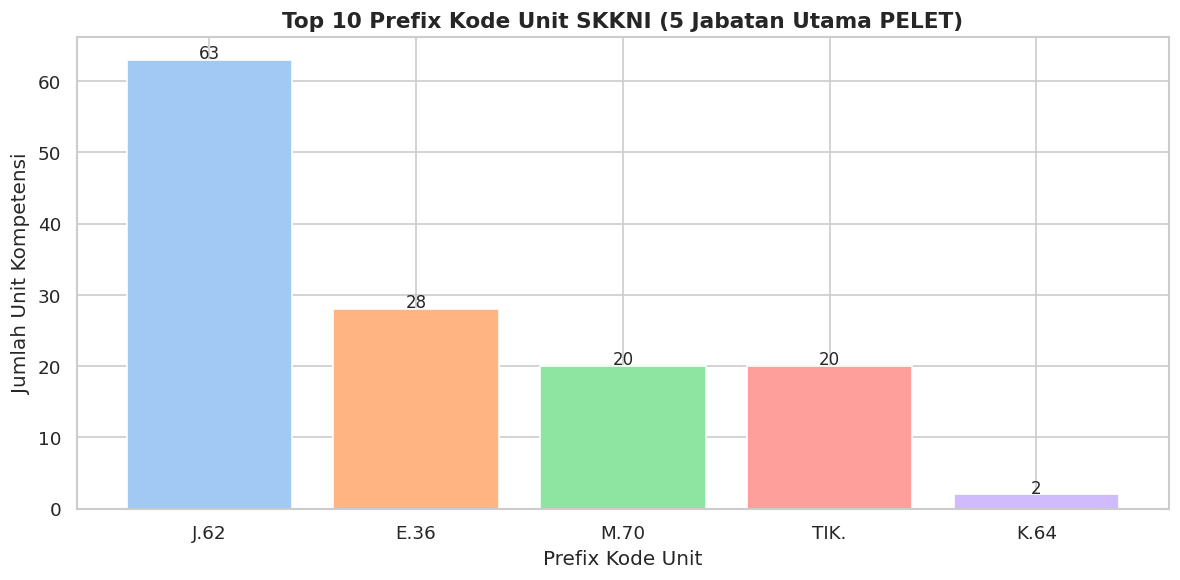

In [14]:
# Analisis Kode Unit SKKNI
skkni_5 = skkni[skkni["Jabatan"].isin(
    ["Programmer", "Data Analyst", "Data Scientist", "Cyber security", "Keuangan"]
)].copy()

# Ekstrak prefix kode unit
skkni_5["kode_prefix"] = skkni_5["Kode Unit"].str[:4]
prefix_counts = skkni_5["kode_prefix"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(prefix_counts.index, prefix_counts.values,
       color=sns.color_palette("pastel", len(prefix_counts)))
ax.set_title("Top 10 Prefix Kode Unit SKKNI (5 Jabatan Utama PELET)", fontsize=13, fontweight="bold")
ax.set_xlabel("Prefix Kode Unit")
ax.set_ylabel("Jumlah Unit Kompetensi")
for i, v in enumerate(prefix_counts.values):
    ax.text(i, v + 0.2, str(v), ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("eda_skkni_prefix.png", bbox_inches="tight")
plt.show()

**Insight:**

Prefix kode unit memberikan gambaran mengenai kluster kompetensi pada dataset SKKNI. Prefix `J.63` dan `C.29` mendominasi jumlah unit kompetensi, yang merujuk pada bidang Teknologi Informasi serta kompetensi terkait Industri 4.0 berdasarkan klasifikasi resmi BNSP.